In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ===================================================
# LOAD DATA
# ===================================================

file_path = "all_data_final_organized_combined-all100mv.xlsx"

df = pd.read_excel(file_path)


tx_power_mW = df["Power of +1st Order [mW]"][df["Power of +1st Order [mW]"].notna()].to_numpy()
average_rx_power_nW = df["Rx Power (1000 Sample averaged) [nW]"][df["Rx Power (1000 Sample averaged) [nW]"].notna()].to_numpy()

raw_BER = df["ub20_acTrue_RAW_BER"].to_numpy()
LDPC_BER = df["ub20_acTrue_LDPC_BER"].to_numpy()

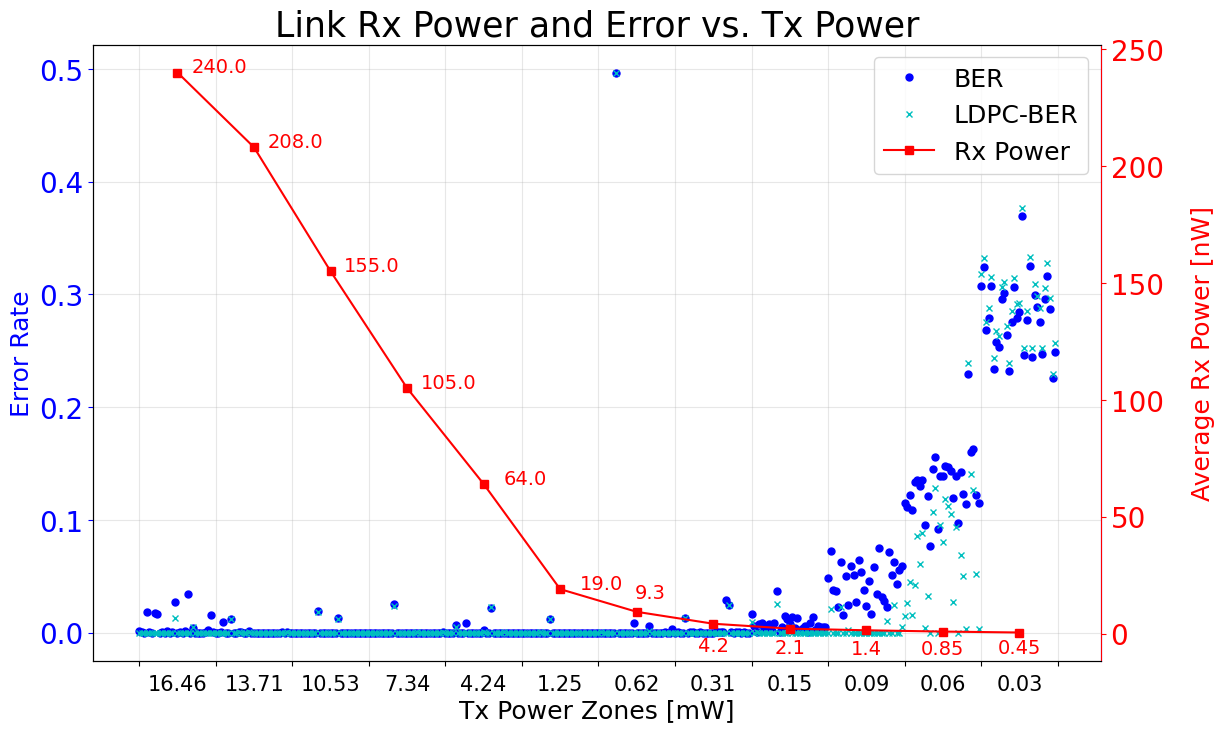

In [28]:
fig, ax = plt.subplots(1,1,figsize = (13,8))

ax.plot(raw_BER, marker='o', linestyle='None', markersize= 5, label = "BER", c = 'b')
ax.plot(LDPC_BER, marker='x', linestyle='None', markersize = 5, label = "LDPC-BER", c = 'c')

tick_positions = np.linspace(0,len(raw_BER),13)
region_labels = np.round(tx_power_mW,2).astype(str)

# 3. Apply them to the x-axis simultaneously
ax.set_xticks(tick_positions)
ax.set_xticklabels([])

ticks = tick_positions


# compute midpoints between ticks
midpoints = (ticks[:-1] + ticks[1:]) / 2

# place labels at midpoints
for m, label in zip(midpoints, region_labels):
    ax.text(
        m,
        ax.get_ylim()[0]-0.03,   # bottom of plot
        label,
        ha='center',
        va='bottom',
        fontsize=15
    )
ax.grid(alpha = 0.3)

ax.set_ylabel("Error Rate", fontsize = 18)

ax.set_xlabel("Tx Power Zones [mW]", labelpad=20, fontsize = 18)




ax2 = ax.twinx()


ax2.plot(midpoints, average_rx_power_nW, 's-', color='red', label='Rx Power')

ax2.set_ylabel("Average Rx Power [nW]", labelpad = 20, fontsize = 18)

ax2.tick_params(axis='y', colors='red')
ax2.yaxis.label.set_color('red')

ax2.spines['right'].set_color('red')

ax.tick_params(axis='y', colors='blue')
ax.yaxis.label.set_color('blue')

ax.spines['right'].set_color('blue')


lines_1, labels_1 = ax.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax.legend(lines_1 + lines_2, labels_1 + labels_2, loc='best', fontsize = 18)



###############
xytexts = [(30,0),
           (30,0),
           (30,0),
           (30,0),
           (30,0),
           (30,0),
           (10,10),
           (0,-20),
           (0,-18),
           (0,-17),
           (0,-16),
           (0,-15)]
iterr = 0
for i, j in zip(midpoints, average_rx_power_nW):
    ax2.annotate(
        text=f'{j}',                # The text label (showing the Y value)
        xy=(i, j),                  # Native coordinates of the data point
        textcoords="offset points", # How to position the text
        xytext=xytexts[iterr],             # Distance from the point (x, y) in points
        ha='center',
        c = 'r',
        fontsize = 14
    
    )
    iterr = iterr + 1


###############



ax.set_title("Link Rx Power and Error vs. Tx Power", fontsize = 25);

ax.tick_params(axis='both', labelsize=20)
ax2.tick_params(axis='both', labelsize=20)


# plt.savefig("link-results.pdf")